In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.optimize import curve_fit
from zero_point import zpt

from scipy.integrate import trapezoid
from scipy.integrate import cumulative_trapezoid
import seaborn as sns
#import pymc as pm
#import pytensor.tensor as pt
#import arviz as az

# Distances using 1/p

In [2]:
#load Riess et al. table
dr2 = pd.read_csv("riess2018gaiadr2.csv", delimiter='  ', engine='python')
dr3 = pd.read_csv("incl. l and b-result.csv")
cross = pd.read_csv("xmatch_riess_col_corr_gaia_source-result.csv")

dr2_coords = SkyCoord(
    ra=dr2["ra"].values * u.deg,
    dec=dr2["dec"].values * u.deg
)

dr3_coords = SkyCoord(
    ra=dr3["ra"].values * u.deg,
    dec=dr3["dec"].values * u.deg
)

idx, sep2d, _ = dr2_coords.match_to_catalog_sky(dr3_coords)

#max separation for sources between dr2 & dr3
match = sep2d < 0.01*u.arcsec

dr2_match = dr2[match].reset_index(drop=True)
dr3_match = dr3.iloc[idx[match]].reset_index(drop=True)

df = pd.concat(
    [dr2_match, dr3_match.add_suffix("_dr3")],
    axis=1
)

#for dr2 only
#df = dr2
df = cross
#dr2_gaiaupload = dr2.drop(columns='#Designation')
#dr2_gaiaupload.to_csv("riess_col_corrected.csv")

M^W_H = (-3.627 +- 0.126) * (logP - 1) + (-5.777 +- 0.026)
# of objects: 41


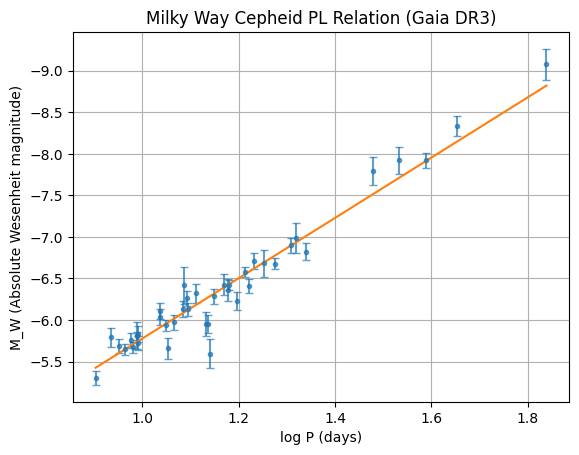

In [3]:
#data
#masking 4 w/ dodgy stats: T MON too close to saturation threshold; others too large uncertainties
#["RY VEL", "RW CAM", "SV PER", "T MON"]
#masking
#NEW BINARIES: ['FO CAR', 'MY PUP', 'R CRU', 'VY PER', 'VZ PUP']
#OLD BINARIES: ['DL CAS', 'FF AQL', 'S MUS', 'S SGE', 'SY NOR', 'TX MON', 'U VUL', 'V1334 CYG', 'YZ CAR']
#extra 2: 'X PUP', 'XX SAG'
binaries = ['FO CAR', 'MY PUP', 'R CRU', 'VY PER', 'VZ PUP', 'DL CAS', 'FF AQL', 'S MUS', 'S SGE', 'SY NOR', 'TX MON', 'U VUL', 'V1334 CYG', 'YZ CAR', 'X PUP', 'XX SAG']
mask = (df["FinalAnalysisFlag"] == 0) & (~df["Name"].isin(binaries))
df46 = df[mask].reset_index(drop=True)
logP = df46["LogPeriod"].values
mWH = df46["mWH"].values
#mWH_err = 
#parallax = df46["parallax"].values       # mas
#parallax_err = df46["parallax_error"].values

#for using dr3
#parallax = df46["parallax_dr3"].values       # mas
#parallax_err = df46["parallax_error_dr3"].values

#for using crossmatch
parallax = df46["parallax.1"].values       # mas
parallax_err = df46["parallax_error.1"].values

#band magnitudes
m_f160w = df46["F160W"].values
m_f555w = df46["F555W"].values
m_f814w = df46["F814W"].values

#band magnitude errors
m_f160w_err = df46["F160W_error"].values
m_f555w_err = df46["F555W_error"].values
m_f814w_err = df46["F814W_error"].values

# count-rate non-linearity correction
crnl = 0.052
crnl_err = 0.014

# apparent Wesenheit magnitude
mWH_calc = m_f160w - 0.386*(m_f555w - m_f814w) + crnl    

mWH_err = np.sqrt(m_f160w_err**2 + (0.386*m_f555w_err)**2 + (0.386*m_f814w_err)**2 + crnl_err**2)
    
#Riess et al. calibration
# M_W = m(logP − 1) + c

def PL(logP, m, c):
    return m * (logP - 1.0) + c

#corrected parallaxes
#zero_point = -0.046 #mas
#zp_err = 0.006      #mas

zpt.load_tables()
zero_point_nan = zpt.get_zpt(
    df46['phot_g_mean_mag.1'], 
    df46['nu_eff_used_in_astrometry'],
    df46['pseudocolour'],
    df46['ecl_lat'],
    df46['astrometric_params_solved']
)
zero_point = np.nan_to_num(zero_point_nan, nan=np.nanmean(zero_point_nan))
zp_err = 0.0

parallax_corr = parallax - zero_point
parallax_corr_err = np.sqrt(parallax_err**2 + zp_err**2)

#absolute Wesenheit magnitude
mu = 5*np.log10(1e3/parallax_corr) - 5
MWH = mWH_calc - mu

#error in abs M_WH
MWH_err = np.sqrt( (5/(np.log(10)) * (parallax_corr_err / parallax_corr))**2 + mWH_err**2 )

#least squares
params, cov = curve_fit(
    PL,
    logP,
    MWH,
    sigma=MWH_err,
)

m, c = params
m_err, c_err = np.sqrt(np.diag(cov))

print(f"M^W_H = ({m:.3f} +- {m_err:.3f}) * (logP - 1) + ({c:.3f} +- {c_err:.3f})")
print(f'# of objects: {len(MWH)}')

#plot
plt.errorbar(logP, MWH, yerr=MWH_err, fmt='.', alpha=0.7, capsize=3)
x = np.linspace(min(logP), max(logP), 200)
plt.plot(x, PL(x, m, c))

plt.gca().invert_yaxis()
plt.xlabel("log P (days)")
plt.ylabel("M_W (Absolute Wesenheit magnitude)")
plt.title("Milky Way Cepheid PL Relation (Gaia DR3)")
plt.grid()
plt.show()

# Distances with $<s>$

In [73]:
# constants (kpc)
#density function
R0 = 8.2        # Sun galactocentric radius
Rd = 3
z0 = 0.3
z0_t = 0.9
a_t = 0.12
a_h = 0.001

#selection function (ignore these)
a = 0.112
c1 = 1.37
d1 = 9.52
d2 = 1.3
c2 = 6.51

# distance grid (kpc)
s = np.linspace(0.001, 25.0, 2000)

#--------------------------------------------------
#gaussian likelihood for parallax (G)
def parallax_likelihood(p, p0, sigma_p):
    return np.exp(-0.5 * ((p - p0) / sigma_p)**2)

#-------------------------------------------------
#density prior (rho)
def density_prior(s, l, b):
    """
    s in kpc
    l, b in radians
    """
    # convert heliocentric distance -> galactocentric coordinates
    x = R0 - s * np.cos(b) * np.cos(l)
    y = -s * np.cos(b) * np.sin(l)
    z = s * np.sin(b)

    R = np.sqrt(x**2 + y**2)
    r = np.sqrt(R**2 + z**2)

    thin = np.exp(-(R - R0) / Rd) * np.exp(-np.abs(z) / z0)
    thick = a_t * np.exp(-(R - R0) / Rd) * np.exp(-np.abs(z) / z0_t)
    halo = a_h * (r / R0) ** (-2.5)

    return thin #+ thick + halo

#-------------------------------------------------
#IGNORE THIS SELECTION FUNCTION

def selection_function(s):
    S = 1              
    return S

#--------------------------------------------------
#distance expectation (<s>)

def bayesian_distance(parallax_mas, parallax_err_mas, l_deg, b_deg):
    """
    Returns expected distance in kpc
    """
    # convert units
    p0 = parallax_mas
    sigma_p = parallax_err_mas
    l = np.radians(l_deg)
    b = np.radians(b_deg)

    # parallax corresponding to distance
    p = 1.0 / s  # mas if s in kpc

    G = parallax_likelihood(p, p0, sigma_p)
    rho = density_prior(s, l, b)
    S = selection_function(s)

    N = trapezoid(s**2 * G * rho * S, x=s)

    posterior = (s**2 * G * rho * S) / N
        
    dist_exp = trapezoid(s**3 * G * rho * S, x=s) / N

    #sigma
    cdf = cumulative_trapezoid(posterior, s, initial=0)
    cdf /= cdf[-1]  #normalisation
    dist_err = np.maximum(np.interp(0.5,cdf,s) - np.interp(0.16,cdf,s), np.interp(0.84,cdf,s) - np.interp(0.5,cdf,s))
    
    return dist_exp, dist_err, posterior


longs = df46['l']
lats = df46['b']
name = df46['Name']
eg = 27

distances = np.array([
    bayesian_distance(p, pe, l, b)[0]
    for p, pe, l, b in zip(parallax_corr,parallax_corr_err,longs,lats)
])

distances_err = np.array([
    bayesian_distance(p, pe, l, b)[1]
    for p, pe, l, b in zip(parallax_corr,parallax_corr_err,longs,lats)
])

#print(distances_err/distances)
#print(parallax_corr_err/parallax_corr)
#print(np.argmax(distances_err/distances))
#print(df46.iloc[np.argmax(distances_err/distances)])

posterior_test = bayesian_distance(parallax_corr[eg], parallax_corr_err[eg], longs[eg], lats[eg])[2]
print((distances[eg]-1/parallax_corr[eg])/distances[eg])

0.034852360923523146


In [74]:
#rel_dist_err = np.sqrt((parallax_corr_err/parallax_corr**2)+(distances_err/distances**2))
rel_dist = (distances-1/parallax_corr)/distances
rel_dist_err = distances_err/distances

mu2 = 5*np.log10(distances) + 10
MWH2 = mWH_calc - mu2
#print(distances)

print(f'# of objects: {len(distances)}')

# of objects: 41


In [72]:
#error in abs M_WH
MWH_err2 = np.sqrt( (5/(np.log(10)) * (distances_err / distances))**2 + mWH_err**2 )

#least squares
params2, cov2 = curve_fit(
    PL,
    logP,
    MWH2,
    sigma=MWH_err2
)

m2, c2 = params2
m_err2, c_err2 = np.sqrt(np.diag(cov2))

print('1/p:')
print(f"M^W_H = ({m:.3f} +- {m_err:.3f}) * (logP - 1) + ({c:.3f} +- {c_err:.3f})")
print(f'# of objects: {len(MWH)}')
print('<s>:')
print(f"M^W_H = ({m2:.3f} +- {m_err2:.3f}) * (logP - 1) + ({c2:.3f} +- {c_err2:.3f})")

1/p:
M^W_H = (-3.627 +- 0.126) * (logP - 1) + (-5.777 +- 0.026)
# of objects: 41
<s>:
M^W_H = (-3.651 +- 0.126) * (logP - 1) + (-5.789 +- 0.026)


In [58]:
# new density of thin disc only

def density_thin(s,l,b, Rd, z0p):

    z = s*np.sin(b)

    R = np.sqrt(R0**2 + (s*np.cos(b))**2 - 2*R0*s*np.cos(b)*np.cos(l))

    rho = np.exp(-(R-R0)/Rd) * np.exp(-np.abs(z)/z0p)

    return rho

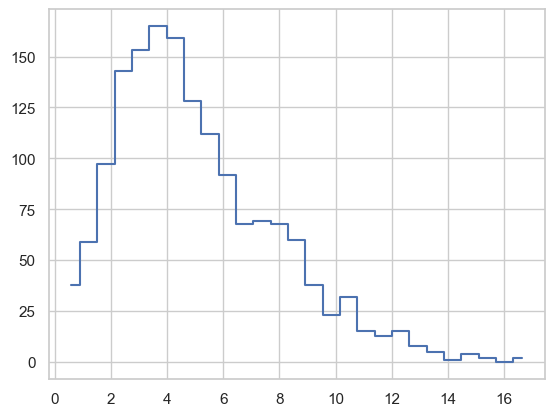

In [18]:
#parallax cuts for histogram
mask_hist = ((dr3['parallax_error']/dr3['parallax'] < 0.2) & (dr3['parallax'] > 0) & (dr3['b'] > -20))
dr3_masked_hist = dr3[mask_hist]
dr3_coords_masked = dr3_coords[mask_hist]
hist_obs, edges = np.histogram(1/dr3_masked_hist['parallax'], bins='fd')
s_mid = 0.5*(edges[1:]+edges[:-1])

plt.step(s_mid, hist_obs, where="mid", label="Observed")


In [19]:
from scipy.optimize import minimize
import emcee
import corner
from astroML.plotting.mcmc import plot_mcmc

c:\users\joshu\appdata\local\programs\python\python39\lib\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


In [54]:
def S_tanh(k):
    return k

l = dr3_coords_masked.galactic.l.value
b = dr3_coords_masked.galactic.b.value
R0 = 8.2


def mean_density(s,Rd, z0p):

    s = s[:,None]

    z = s * np.sin(b)
    
    R = np.sqrt(
        R0**2
        + (s*np.cos(b))**2
        - 2*R0*s*np.cos(b)*np.cos(l)
    )

    rho = np.exp(-(R-R0)/Rd) * np.exp(-np.abs(z)/z0p)

    return rho.mean(axis=1)

def model_pdf(s, params):

    Rd, z0p, k = params

    rho = mean_density(s, Rd, z0p)

    pdf = s**2 * rho * S_tanh(k)

    norm = np.trapz(pdf, s)

    return pdf / norm

def loglike(params):

    pdf = model_pdf(s, params)

    p = np.interp(1/dr3_masked_hist['parallax'].values, s, pdf)

    p[p <= 0] = 1e-12

    return np.sum(np.log(p))

def logprior(params):

    Rd, z0p, k = params

    if 1 < Rd < 4.4 and 0.05 < z0p < 1 and 0.1 < k < 1:
        return 0

    return -np.inf

def logposterior(params):

    lp = logprior(params)

    if not np.isfinite(lp):
        return -np.inf

    return lp + loglike(params)


In [66]:
ndim = 3
nwalkers = 32

p0 = np.array([3, 0.2, 0.5])

pos = p0 + 1e-3*np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    logposterior
)

sampler.run_mcmc(pos, 1000, progress=True);

100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [1:47:37<00:00,  6.46s/it]


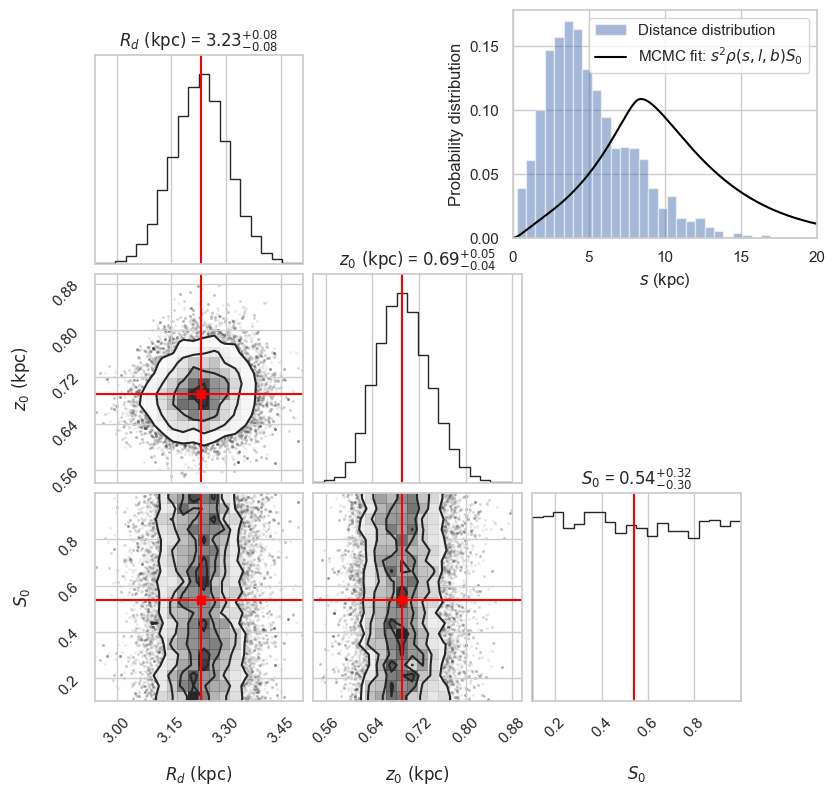

In [68]:
samples = sampler.get_chain(discard=100, flat=True)

Rd_samples = samples[:,0]
z0p_samples = samples[:,1]
k_samples = samples[:,2]

#corner.corner(
#    samples,
#    labels=["Scale length of disc","Limiting distance","Width","Skewness"]
#);

labels = [
    r"$R_d\ (\mathrm{kpc})$",
    r"$z_0\ (\mathrm{kpc})$",
    r"$S_0$"
]

#median and 1-sigma
medians = np.median(samples, axis=0)
lower = np.percentile(samples, 16, axis=0)
upper = np.percentile(samples, 84, axis=0)

#corner plot
fig = corner.corner(
    samples,
    labels=labels,
    truths=medians,
    truth_color='red',
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 12}
)

fig.subplots_adjust(bottom=0.1, top=0.95,
                left=0.1, right=0.95,
                hspace=0.05, wspace=0.05)

best = np.median(samples, axis=0)

pdf = model_pdf(s, best)
ax = fig.add_axes([0.65, 0.71, 0.4, 0.3])
ax.hist(1/dr3_masked_hist['parallax'].values, bins="fd", density=True, alpha=0.5, label='Distance distribution')
ax.plot(s, pdf, label=r'MCMC fit: $s^2 \rho (s,l,b) S_0$', color='black')

ax.set_xlabel("$s$ (kpc)")
ax.set_xlim(0,20)
ax.set_ylabel("Probability distribution")
ax.legend();

plt.savefig('mcmc_flatS.pdf', bbox_inches='tight')

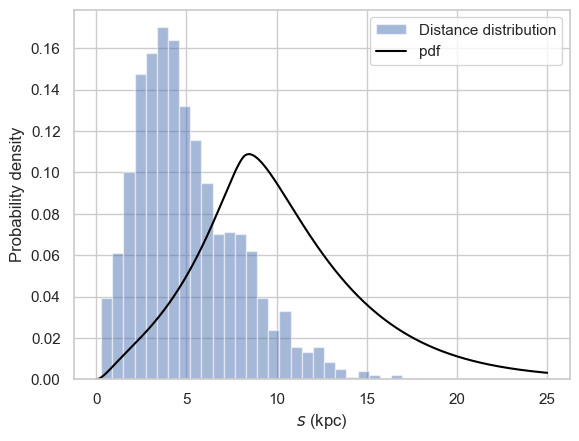

In [69]:
best = np.median(samples, axis=0)

pdf = model_pdf(s, best)

plt.hist(1/dr3_masked_hist['parallax'].values, bins="fd", density=True, alpha=0.5, label='Distance distribution')
plt.plot(s, pdf, label='pdf', color='black')

plt.xlabel("$s$ (kpc)")
plt.ylabel("Probability density")
plt.legend();

1/p:
M^W_H = (-3.627 +- 0.126) * (logP - 1) + (-5.777 +- 0.026)
# of objects: 41
<s>:
M^W_H = (-3.651 +- 0.126) * (logP - 1) + (-5.789 +- 0.026)


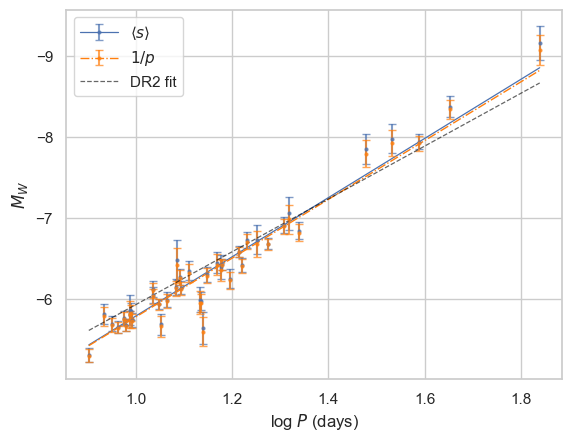

In [70]:
### distance estimation WITH FLAT PRIOR
def bayesian_distance2(parallax_mas, parallax_err_mas, l_deg, b_deg, best):
    """
    Returns expected distance in kpc
    """
    # convert units
    p0 = parallax_mas
    sigma_p = parallax_err_mas
    l = np.radians(l_deg)
    b = np.radians(b_deg)

    # parallax corresponding to distance
    p = 1.0 / s  # mas if s in kpc

    G = parallax_likelihood(p, p0, sigma_p)
    rho = density_thin(s, l, b, best[0], best[1])
    S = S_tanh(best[2])

    N = trapezoid(s**2 * G * rho * S, x=s)

    posterior = (s**2 * G * rho * S) / N
        
    dist_exp = trapezoid(s**3 * G * rho * S, x=s) / N

    #sigma
    cdf = cumulative_trapezoid(posterior, s, initial=0)
    cdf /= cdf[-1]  #normalisation
    dist_err = np.maximum(np.interp(0.5,cdf,s) - np.interp(0.16,cdf,s), np.interp(0.84,cdf,s) - np.interp(0.5,cdf,s))
    
    return dist_exp, dist_err, posterior


longs = df46['l']
lats = df46['b']
name = df46['Name']
eg = 27

distances = np.array([
    bayesian_distance2(p, pe, l, b, best)[0]
    for p, pe, l, b in zip(parallax_corr,parallax_corr_err,longs,lats)
])

distances_err = np.array([
    bayesian_distance2(p, pe, l, b, best)[1]
    for p, pe, l, b in zip(parallax_corr,parallax_corr_err,longs,lats)
])

#error in abs M_WH
MWH_err2 = np.sqrt( (5/(np.log(10)) * (distances_err / distances))**2 + mWH_err**2 )

#least squares
params2, cov2 = curve_fit(
    PL,
    logP,
    MWH2,
    sigma=MWH_err2
)

m2, c2 = params2
m_err2, c_err2 = np.sqrt(np.diag(cov2))

print('1/p:')
print(f"M^W_H = ({m:.3f} +- {m_err:.3f}) * (logP - 1) + ({c:.3f} +- {c_err:.3f})")
print(f'# of objects: {len(MWH)}')
print('<s>:')
print(f"M^W_H = ({m2:.3f} +- {m_err2:.3f}) * (logP - 1) + ({c2:.3f} +- {c_err2:.3f})")

#print(MWH2[39])
#print()

#plot
#plt.figure(figsize=(12,8))
#<s> distances
s_points = plt.errorbar(logP, MWH2, yerr=MWH_err2, fmt='.', alpha=0.7, capsize=3,color='b',ms=4)
x = np.linspace(min(logP), max(logP), 200)
s_line, = plt.plot(x, PL(x, m2, c2), linewidth=0.9, color='b')
#1/p distances
p_points = plt.errorbar(logP, MWH, yerr=MWH_err, fmt='.', alpha=0.7, capsize=3,color='tab:orange',ms=4)
p_line, = plt.plot(x, PL(x, m, c), linewidth=1, color='tab:orange', linestyle='-.')

other_line, = plt.plot(x, PL(x, m_r, c_r), linewidth=0.9, color='black', linestyle='--', alpha=0.6)

plt.gca().invert_yaxis()
plt.xlabel(r"log $P$ (days)")
plt.ylabel(r"$M_W$")
#plt.title("Milky Way Cepheid PL Relation (Gaia DR3, Bayesian distances)")
plt.legend(
    [(s_points,s_line),(p_points,p_line),other_line],
    [r'$\langle s \rangle$',r'$1/p$','DR2 fit'],
    fontsize=11,
    handlelength=2.5
)
plt.savefig('pl_final_flatS.pdf')

In [65]:
m_r = -3.26
c_r = -5.93
H0_pref = 73.24
H0_mw = 76.18

m_rc = -3.294
c_rc = -5.88

dPL = (m2*(np.mean(logP)-1) + c2) - (m_r*(np.mean(logP)-1) + c_r)
#fainter cepheids => mu smaller => closer => less expansion => H_0 decreases
dPL_percent = dPL/np.abs((m_r*(np.mean(logP)-1) + c_r))

dH0 = 10**(dPL/5) - 1   #factor of H0

H0_new = (dH0+1)*H0_mw

print(f"delta M_W = {dPL:.3f} ~ {dPL_percent*100:.2f}%")
print(f"{dH0*100:.2f}% change in H0")
print(f"to {H0_new:.2f} (from 1 anchor, MW Cepheids {H0_mw})")
print(f"or to {(dH0+1)*H0_pref:.2f} (from preferred, 3 anchors {H0_pref})")

delta M_W = 0.075 ~ 1.15%
3.50% change in H0
to 78.85 (from 1 anchor, MW Cepheids 76.18)
or to 75.80 (from preferred, 3 anchors 73.24)
